In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency, kruskal
from statannotations.Annotator import Annotator

from SSNHL.util import load_data

In [2]:
raw_data = load_data('../raw_data/all.xlsx', preprocess_func=None)
raw_data = raw_data.rename(columns={'prognostic(no_recovery=0, minor_recovery=1, important_recovery=2, full_recovery=3)': 'prognostic'})
raw_data

,Gender,Age,Left ear/Right ear,Days from onset to treatment(absolute),days from onset to treatment (categorized),Vertigo,Ear blockage,Tinnitus,Hypertension,Diabetes,...,Mean hearing threshold (affected side),WHO classify (affected side),Curve type (affected side),Mean hearing threshold (contralateral),WHO classify (contralateral),Curve type (contralateral),loudness recruitment(affected side),ABR,DPOAE response,prognostic
patient NO.,,,,,,,,,,,,,,,,,,,,,
4,0,28,R,1,0,0,1,1,0,0,...,49.0,2,upsloping,-1.0,0.0,normal,1.0,0.0,1.0,3
455,0,33,L,15,2,0,1,1,0,0,...,18.0,0,upsloping,0.0,0.0,normal,1.0,0.0,1.0,0
405,0,30,L,10,1,1,0,1,0,0,...,105.0,4,profound,1.0,0.0,normal,0.0,1.0,0.0,0
264,0,27,R,6,0,1,1,1,0,0,...,21.0,0,upsloping,3.0,0.0,normal,1.0,0.0,1.0,3
458,0,29,R,15,2,0,1,1,0,0,...,23.0,0,upsloping,3.0,0.0,normal,0.0,NaN,1.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208,0,75,L,5,0,0,1,0,0,0,...,120.0,4,profound,120.0,4.0,profound,0.0,1.0,0.0,0
476,0,42,L,20,2,0,1,1,0,0,...,18.0,0,upsloping,NaN,NaN,normal,1.0,0.0,1.0,3
489,1,54,L,20,2,0,1,1,0,0,...,74.0,3,flat,NaN,NaN,NaN,0.0,NaN,NaN,0


In [3]:
data = raw_data.copy()
data = data.fillna('-')

data.loc[data['prognostic'] == 0, 'prognostic'] = 'no recovery'
data.loc[data['prognostic'] == 1, 'prognostic'] = 'minor recovery'
data.loc[data['prognostic'] == 2, 'prognostic'] = 'important recovery'
data.loc[data['prognostic'] == 3, 'prognostic'] = 'full recovery'
data['prognostic'] = pd.Categorical(data['prognostic'], ['no recovery', 'minor recovery', 'important recovery', 'full recovery'])

data

,Gender,Age,Left ear/Right ear,Days from onset to treatment(absolute),days from onset to treatment (categorized),Vertigo,Ear blockage,Tinnitus,Hypertension,Diabetes,...,Mean hearing threshold (affected side),WHO classify (affected side),Curve type (affected side),Mean hearing threshold (contralateral),WHO classify (contralateral),Curve type (contralateral),loudness recruitment(affected side),ABR,DPOAE response,prognostic
patient NO.,,,,,,,,,,,,,,,,,,,,,
4,0,28,R,1,0,0,1,1,0,0,...,49.0,2,upsloping,-1.0,0.0,normal,1.0,0.0,1.0,full recovery
455,0,33,L,15,2,0,1,1,0,0,...,18.0,0,upsloping,0.0,0.0,normal,1.0,0.0,1.0,no recovery
405,0,30,L,10,1,1,0,1,0,0,...,105.0,4,profound,1.0,0.0,normal,0.0,1.0,0.0,no recovery
264,0,27,R,6,0,1,1,1,0,0,...,21.0,0,upsloping,3.0,0.0,normal,1.0,0.0,1.0,full recovery
458,0,29,R,15,2,0,1,1,0,0,...,23.0,0,upsloping,3.0,0.0,normal,0.0,-,1.0,full recovery
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208,0,75,L,5,0,0,1,0,0,0,...,120.0,4,profound,120.0,4.0,profound,0.0,1.0,0.0,no recovery
476,0,42,L,20,2,0,1,1,0,0,...,18.0,0,upsloping,-,-,normal,1.0,0.0,1.0,full recovery
489,1,54,L,20,2,0,1,1,0,0,...,74.0,3,flat,-,-,-,0.0,-,-,no recovery


In [6]:
after_treatment_data = pd.read_excel("../raw_data/after_treatment.xlsx", index_col=0, header=[0])
data = pd.merge(data, after_treatment_data, on="patient NO.", how="inner")
data

,Gender,Age,Left ear/Right ear,Days from onset to treatment(absolute),days from onset to treatment (categorized),Vertigo,Ear blockage,Tinnitus,Hypertension,Diabetes,...,Curve type (affected side),Mean hearing threshold (contralateral),WHO classify (contralateral),Curve type (contralateral),loudness recruitment(affected side),ABR,DPOAE response,prognostic,Mean hearing threshold (affected side) after treatment,WHO classify (affected side) after treatment
patient NO.,,,,,,,,,,,,,,,,,,,,,
4,0,28,R,1,0,0,1,1,0,0,...,upsloping,-1.0,0.0,normal,1.0,0.0,1.0,full recovery,30,1
455,0,33,L,15,2,0,1,1,0,0,...,upsloping,0.0,0.0,normal,1.0,0.0,1.0,no recovery,20,0
405,0,30,L,10,1,1,0,1,0,0,...,profound,1.0,0.0,normal,0.0,1.0,0.0,no recovery,94,4
264,0,27,R,6,0,1,1,1,0,0,...,upsloping,3.0,0.0,normal,1.0,0.0,1.0,full recovery,8,0
458,0,29,R,15,2,0,1,1,0,0,...,upsloping,3.0,0.0,normal,0.0,-,1.0,full recovery,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208,0,75,L,5,0,0,1,0,0,0,...,profound,120.0,4.0,profound,0.0,1.0,0.0,no recovery,120,4
476,0,42,L,20,2,0,1,1,0,0,...,upsloping,-,-,normal,1.0,0.0,1.0,full recovery,8,0
489,1,54,L,20,2,0,1,1,0,0,...,flat,-,-,-,0.0,-,-,no recovery,76,3


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

important recovery vs. full recovery: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.228e-32 U_stat=1.152e+04
no recovery vs. minor recovery: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:3.585e-02 U_stat=1.391e+04
minor recovery vs. important recovery: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.000e+00 U_stat=3.710e+03
minor recovery vs. full recovery: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:2.146e-28 U_stat=9.366e+03
no recovery vs. important recovery: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:2.844e-03 U_stat=1.752e+04
no recovery vs. full recovery: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.549e-53 U_stat=3.759e+04


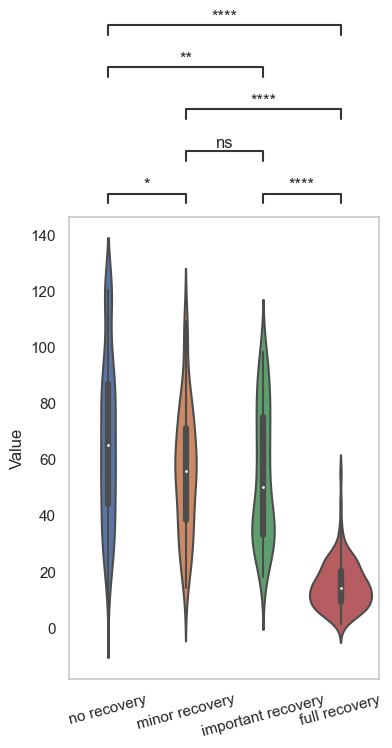

In [23]:
def violinplot(data, x=None, y=None, hue=None, pairs=None, xlabel=None, ylabel=None, xticklabels=None, output_path: str = None, figsize: tuple = (24, 12)):
    sns.set_theme(style="whitegrid")

    fig, ax = plt.subplots(figsize=figsize)

    ax = sns.violinplot(data=data, x=x, y=y, hue=hue)

    if pairs:
        annotator = Annotator(ax, pairs, data=data, x=x, y=y, hue=hue)
        annotator.configure(test='Mann-Whitney', text_format='star', loc='outside', comparisons_correction="Bonferroni")
        annotator.apply_and_annotate()

    # plt.legend()
    plt.grid(False)

    if xlabel is not None:
        plt.xlabel(xlabel)
    if ylabel is not None:
        plt.ylabel(ylabel)
    if xticklabels:
        ax.set_xticklabels(labels=xticklabels)
    plt.xticks(rotation=15)

    if output_path:
        plt.savefig(output_path, bbox_inches="tight")
    plt.show()

_data = data[[
    # "Mean hearing threshold (affected side)",
    "Mean hearing threshold (affected side) after treatment",
    "prognostic"
]].copy()
_data = _data[~_data.apply(lambda row: row.astype(str).str.contains('-').any(), axis=1)]
_data = pd.melt(_data, value_vars=[
    # "Mean hearing threshold (affected side)",
    "Mean hearing threshold (affected side) after treatment"
    ], id_vars=['prognostic'])
_data['value'] = _data['value'].astype(float)

column = "Mean hearing threshold (affected side) after treatment"
_prognostic = _data['prognostic'].unique()
pairs = [
    ((_prognostic[i], _prognostic[j]))
    for i in range(len(_prognostic))
    for j in range(i+1, len(_prognostic))
]


violinplot(
    _data[_data['variable']==column],
    x='prognostic',
    y='value',
    # hue='',
    pairs=pairs,
    xlabel='',
    ylabel='Value',
    # ylabel='Accuracy',
    figsize=(4, 6),
    output_path='../output/distribution/consecutive/{}_distribution.pdf'.format(column.replace("/", "\\")),
)